# Function 4: Fast, but Inaccurate Modelling
This example is for a particular business relying heavily on online sales. It can run very accurate calculations to figure out what is the optimal placement of their product across warehouses. Unfortunately, the calculations are extremely expensive (computationally) to run, so they can only do it once every two weeks. Instead, they propose using a machine learning model which approximates the solution quickly (in a few hours). The model has four hyper-parameters you need to tune, and the output corresponds to the difference between the expensive calculation, and the model. Since you are modelling a dynamical system, expect a lot of local optima!

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

In [18]:
def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')


# Get input and outputs from submissions
inputs_array = get_input_points(4)
outputs_array = get_output_points(4)


# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)

New shape of X: (41, 4)
New shape of Y: (41,)


In [19]:
# define the number of points per dimension and the number of dimensions
points_per_dimension = 4
dimensions = 4

# create a list of linspace arrays for each dimension
grid_points = [np.linspace(0.000001, 0.999999, points_per_dimension) for _ in range(dimensions)]

# Use itertools.product to generate the grid points on demand
from itertools import product
X_grid = np.array(list(product(*grid_points)))

print(X_grid.shape)

(256, 4)


Current best point: [0.57776561 0.42877174 0.42582587 0.24900741]
Current best output: -4.025542281908162
Candidate range min: [0.23408427 0.37909132 0.37796186 0.08151656]
Candidate range max: [0.62582272 0.55564606 0.5784082  0.29493101]


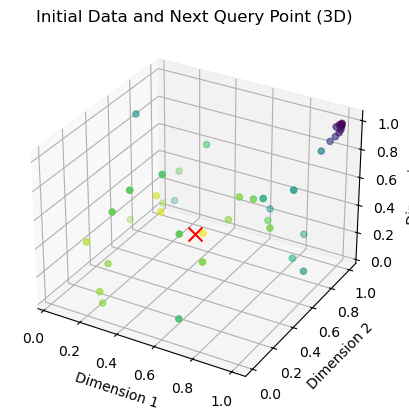

Next Query Point: 0.531333-0.431899-0.401642-0.294407


In [20]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

kernel = Matern(nu=2.5)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-6,
    normalize_y=True,
    random_state=42,
)

gp.fit(X_scaled, y)

rng = np.random.default_rng(42)

# Function 4 is also a maximization problem, so we search around the best observed outputs.
top_indices = np.argsort(y)[-3:]
top_points = X_scaled[top_indices]
best_idx = np.argmax(y)
best_point = X[best_idx]
print("Current best point:", best_point)
print("Current best output:", y[best_idx])

radius = 0.05
local_clouds = []
for point in top_points:
    local_clouds.append(point + rng.uniform(-radius, radius, size=(5000, 4)))

X_candidates = np.vstack(local_clouds)
X_candidates = np.clip(X_candidates, 0, 1)
print("Candidate range min:", scaler.inverse_transform(X_candidates).min(axis=0))
print("Candidate range max:", scaler.inverse_transform(X_candidates).max(axis=0))

kappa = 0.1

mean, std = gp.predict(X_candidates, return_std=True)
ucb = mean + kappa * std

next_scaled = X_candidates[np.argmax(ucb)]
next_query = scaler.inverse_transform(next_scaled.reshape(1, -1))[0]

# Define grid of points
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
x3 = np.linspace(X[:, 2].min(), X[:, 2].max(), 20)
x4 = np.linspace(X[:, 3].min(), X[:, 3].max(), 20)
x1, x2, x3, x4 = np.meshgrid(x1, x2, x3, x4)
X_grid = np.column_stack((x1.ravel(), x2.ravel(), x3.ravel(), x4.ravel()))

# Visualization, showing only 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2],  c=y, cmap='viridis')
ax.scatter(next_query[0], next_query[1], next_query[2], marker='x', color='red', s=100)
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

ax.set_title("Initial Data and Next Query Point (3D)")
plt.show()

# Format the next query point
formatted_next_query = f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}"
print("Next Query Point:", formatted_next_query)